Ejercicio Python 2: Simulación de inversión periódica (Dollar Cost Averaging)
Aplicar simulaciones para comparar dos estrategias de inversión: aportaciones periódicas frente a inversión única inicial.

Selecciona un activo financiero y descarga precios históricos de al menos 3 años.

Define dos estrategias de inversión con un monto total de $5,000:

Inversión única: se invierte todo el monto al inicio del periodo.

Inversión periódica (DCA): se invierten $100 cada semana hasta completar $5,000.

Simula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).

Calcula y compara para ambas estrategias:

Valor final promedio de la inversión.

Desviación estándar del valor final.

Probabilidad de que el valor final sea menor al capital invertido.

Construye gráficos:

Histogramas comparativos de los valores finales.

Evolución promedio de la inversión bajo ambas estrategias.

Redacta un análisis breve, usando markdown en tu notebook, respondiendo:

¿En qué condiciones es más ventajosa la inversión periódica?

¿Cuándo es preferible la inversión en un solo momento?

Edgardo Noel Gonzalez Tejeda

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
price = yf.download("^GSPC",  start = "2018-01-01")["Close"]
price.head(5)

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2018-01-02,2695.810059
2018-01-03,2713.060059
2018-01-04,2723.989990
2018-01-05,2743.149902
2018-01-08,2747.709961


Define dos estrategias de inversión con un monto total de $5,000:

Inversión única: se invierte todo el monto al inicio del periodo.

Inversión periódica (DCA): se invierten $100 cada semana hasta completar $5,000.

Simula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).**

In [4]:
price_weekly = price.resample('W').last()

log_returns = np.log(price_weekly / price_weekly.shift(1)).dropna()

mu_weekly = log_returns.mean()
sigma_weekly = log_returns.std()

print("Mean annual return:", mu_weekly * 52 * 100)
print("Annual volatility:", sigma_weekly * np.sqrt(52) * 100)

Mean annual return: Ticker
^GSPC    11.111135
dtype: float64
Annual volatility: Ticker
^GSPC    18.502535
dtype: float64


Configuramos la simulación

In [7]:
S0 = float(price_weekly.iloc[-1])

num_simulations = 10000
num_weeks = 50

/var/folders/cn/my933gt17y14xgky653gjx400000gn/T/ipykernel_99289/2555097019.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(price_weekly.iloc[-1])


Simulamos las 10,000 trayectorias

In [5]:
mu_weekly = float(log_returns.mean())
sigma_weekly = float(log_returns.std())

/var/folders/cn/my933gt17y14xgky653gjx400000gn/T/ipykernel_99289/987333780.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu_weekly = float(log_returns.mean())
/var/folders/cn/my933gt17y14xgky653gjx400000gn/T/ipykernel_99289/987333780.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_weekly = float(log_returns.std())


In [8]:
np.random.seed(42)

Z = np.random.standard_normal((num_weeks, num_simulations))

prices = np.zeros((num_weeks + 1, num_simulations))
prices[0] = S0

drift = mu_weekly - 0.5 * sigma_weekly**2  

for t in range(1, num_weeks + 1):
    
    shock = sigma_weekly * Z[t-1]
    
    prices[t] = prices[t-1] * np.exp(drift + shock)

Calcula y compara para ambas estrategias:**

Valor final promedio de la inversión.

Desviación estándar del valor final.

Probabilidad de que el valor final sea menor al capital invertido.

In [9]:
weekly_investment = 100

**Estrategia 1:**

In [10]:
initial_investment = weekly_investment * num_weeks

shares_lump = initial_investment / S0

final_lump = shares_lump * prices[-1]

mean_lump = np.mean(final_lump)
std_lump = np.std(final_lump)
prob_loss_lump = np.mean(final_lump < initial_investment)

print("Valor final promedio:", mean_lump)
print("Desviación estándar:", std_lump)
print("Probabilidad de pérdida:", prob_loss_lump)

Valor final promedio: 5555.795046480712
Desviación estándar: 1020.104672256965
Probabilidad de pérdida: 0.3103


**Estrategia 2:**

In [11]:
shares_dca = np.zeros(num_simulations)

for t in range(num_weeks):
    shares_dca += weekly_investment / prices[t]

final_dca = shares_dca * prices[-1]

total_invested = weekly_investment * num_weeks

mean_dca = np.mean(final_dca)
std_dca = np.std(final_dca)
prob_loss_dca = np.mean(final_dca < total_invested)

print("Valor final promedio:", mean_dca)
print("Desviación estándar:", std_dca)
print("Probabilidad de pérdida:", prob_loss_dca)

Valor final promedio: 5275.107663162997
Desviación estándar: 574.8901825272881
Probabilidad de pérdida: 0.3366


In [12]:
results = pd.DataFrame({
    "Estrategia": ["Lump Sum", "DCA"],
    "Valor Promedio": [mean_lump, mean_dca],
    "Desviación Estándar": [std_lump, std_dca],
    "Probabilidad de Pérdida": [prob_loss_lump, prob_loss_dca]
})

results

,Estrategia,Valor Promedio,Desviación Estándar,Probabilidad de Pérdida
0,Lump Sum,5555.795046,1020.104672,0.3103
1,DCA,5275.107663,574.890183,0.3366


**5. Construye gráficos:**

Histogramas comparativos de los valores finales.

Evolución promedio de la inversión bajo ambas estrategias.

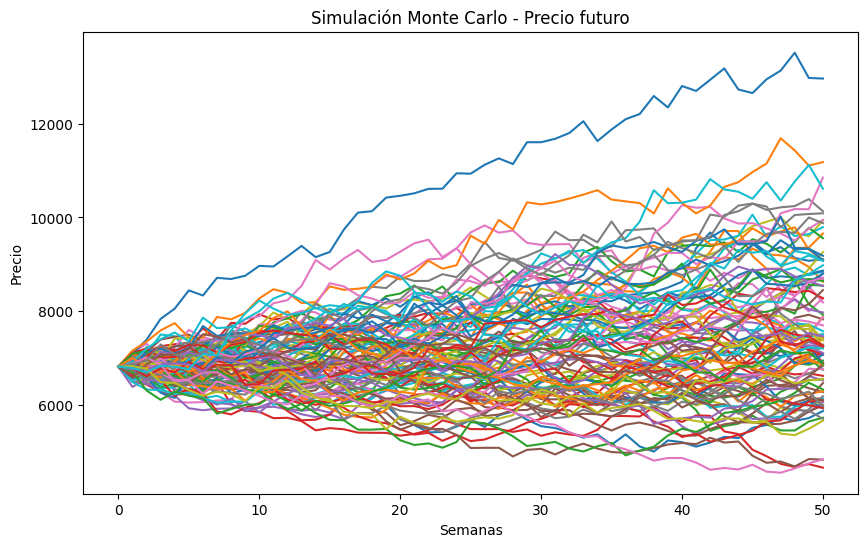

In [13]:
plt.figure(figsize=(10,6))
plt.plot(prices[:, :100])
plt.title("Simulación Monte Carlo - Precio futuro")
plt.xlabel("Semanas")
plt.ylabel("Precio")
plt.show()

Redacta un análisis breve, usando markdown en tu notebook, respondiendo:**

- ¿En qué condiciones es más ventajosa la inversión periódica?

La inversión periódica resulta más conveniente en escenarios de alta volatilidad e incertidumbre, 
sobre todo cuando existe la posibilidad de que los precios bajen al comienzo del periodo de inversión. 
Al distribuir el capital en el tiempo, se obtiene un precio promedio de compra más favorable y se 
minimiza el riesgo de entrar en un momento desfavorable. En mi simulación con el S&P 500, si bien el 
rendimiento promedio fue inferior al de Lump Sum, la dispersión de resultados fue considerablemente 
menor, lo que la convierte en una mejor opción para perfiles de inversión más conservadores que 
priorizan la estabilidad sobre la rentabilidad máxima.

- ¿Cuándo es preferible la inversión en un solo momento?

La inversión en un solo momento (Lump Sum) es la mejor alternativa cuando el activo muestra una 
tendencia alcista sostenida y un retorno esperado positivo, tal como se observó en esta simulación 
con el S&P 500. Concentrar el capital desde el inicio permite que el dinero genere rendimientos 
durante un mayor período, lo que se traduce en un valor final promedio más alto. A pesar de exponer 
al inversionista a una mayor variabilidad, esta estrategia demuestra mejores resultados en índices 
con crecimiento histórico consistente como el S&P 500.